## Lattice version

In [139]:
n_matrix_dimension,q_prime,p_prime,d_f = 107, 67, 3, 14 ## Matrix Dimension, Prime, Prime, Degree of Frobenius
n_matrix_dimension,p_prime,q_prime,d_f = 257,3,2^10,77 ## Matrix Dimension, Prime, Prime, Degree of Frobenius

### Column vectors notation
#### Don't care about this part, it is for completeness pourposes only

In [ ]:
import hashlib

def Tstar(v):
    return matrix.circulant(v).T

def __balanced_remainder__(a,b):
    a = a.mod(b)
    if a > b//2:
        return a-b
    else: 
        return a

def __random_f__():
    aux = [0 for ii in range(n)]
    count = 0
    while count <= d_f:
        jj = floor(n*random())
        if aux[jj]==0:
            aux[jj] = ZZ.random_element(p-1)+1
            count += 1
    count = 0
    while count < d_f:
        jj = floor(n*random())
        if aux[jj]==0:
            aux[jj] = -ZZ.random_element(p-1)+1
            count += 1
    return vector(ZZ,aux)

def __random_r__c():
    aux = [0 for ii in range(n)]
    count = 0
    while count <= d_f:
        jj = floor(n*random())
        if aux[jj]==0:
            aux[jj] = 1
            count += 1
    count = 0
    while count < d_f:
        jj = floor(n*random())
        if aux[jj]==0:
            aux[jj] = -1
            count += 1
    return vector(ZZ,aux)

def NTRU_key_gen(n_matrix_dimension,p_prime,q_prime): ##Maybe we need DF here??
    f_priv_key = __random_f__()
    f_priv_key += vector(ZZ,[1]+[0 for ii in range(n_matrix_dimension-1)])
    Aux = Tstar(f_priv_key)
    auxdet = Aux.determinant()
    while (auxdet.gcd(q_prime) != 1) or (auxdet.gcd(p_prime) != 1):
        f_priv_key = __random_f__()
        f_priv_key += vector(ZZ,[1]+[0 for ii in range(n-1)])
        Aux = Tstar(f_priv_key)
        auxdet = Aux.determinant()
    Aux = Tstar(vector(Zmod(q_prime),list(f_priv_key)))
    g_poly = __random_r__()
    h_pub_key = Aux^-1*g_poly
    h_pub_key = vector(ZZ,list(h_pub_key))
    return f_priv_key,g_poly,h_pub_key

def NTRU_encap(h_pub_key):
    r = __random_r__()
    m = __random_r__()
    aux = p_prime*Tstar(h_pub_key)*r
    aux = vector([ele.mod(q_prime) for ele in list(aux)])
    chain_m = ''
    for ii in range(n_matrix_dimension):
        chain_m += Integer(m[ii]).binary()
    return m + aux, Integer('0x'+hashlib.sha256(chain_m.encode('utf-8')).hexdigest()).binary()

def NTRU_decap(f_priv_key,g,c):
    aux = Tstar(f_priv_key)*c
    aux = vector([ele.mod(q_prime) for ele in list(aux)])
    aux = vector([__balanced_remainder__(ele,q) for ele in list(aux)])
    aux = vector([ele.mod(p_prime) for ele in list(aux)])
    aux = vector([__balanced_remainder__(ele,p_prime) for ele in list(aux)])
    Aux = Tstar(vector(Zmod(p_prime),list(f_priv_key)))
    aux = Aux^-1*aux
    aux = vector(ZZ,list(aux))
    aux = vector([__balanced_remainder__(ele,p_prime) for ele in list(aux)])
    chain_m = ''
    for ii in range(n_matrix_dimension):
        chain_m += Integer(aux[ii]).binary()
    return Integer('0x'+hashlib.sha256(chain_m.encode('utf-8')).hexdigest()).binary()

In [3]:
f_priv_key, g_poly, h_pub_key = NTRU_key_gen(n,p,q)
print(f"f_priv_key = {f_priv_key}")
print(f"g_poly = {g_poly}")
print(f"h_pub_key = {h_pub_key}")

f_priv_key = (3, 1, 2, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 2, 0, 0, 1, 0, 0, 1, 1, 0, 2, 0, 2, 0, 1, 2, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 2, 2, 0, 1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 2, 1, 1, 2, 0, 2, 1, 1, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 2, 1, 1, 0, 1, 2, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 2, 1, 0, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 0, 1, 1, 2, 0, 0, 0, 2, 0, 1, 1, 2, 1, 2, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 2, 0, 2, 0, 2, 0, 1, 0, 0, 0, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 2, 1, 2, 0, 1, 1, 0, 0, 0, 0, 1, 2, 1, 0, 2, 0, 1, 1, 1, 2, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0)
g_poly = (-1, -1, 1, 1, 0, 0, 1, -1, 1, -1, 0, 1, 0, 1, -1, 1, 1, -1, 0, 0, 0, -1, -1, 0, 0, 0, -1, 1, -1, 0, 0, 1, 1, 0, 1, -1, -1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, -1, 0, -1, -1, 1, -1, 0, 0, 0, 1, -1, 1, 0, 0, 1,

In [6]:
encap = NTRU_encap(h_pub_key)

In [10]:
decap = NTRU_decap(f_priv_key,g_poly,encap[0])

In [11]:
encap[1] == decap

True

### Row vector notation

In [128]:
import hashlib
from dataclasses import dataclass
from sage.modules.vector_integer_dense import Vector_integer_dense as vector_integer_dense
"""
@dataclass 
class NTRU_Keyset:
    h_pub_key: vector_integer_dense
    f_priv_key: vector_integer_dense
    g_poly_ring: vector_integer_dense

    def create_tstar_from_vector(self, vector):
        return matrix.circulant(vector)

    

    def __balanced_remainder__(a,b):
        a = a.mod(b)
        if a > b//2:
            return a-b
        else:
            return a



    def __init__(self, matrix_dimension, p_prime, q_prime, degree_of_frobenius):
    f = __random_f__()
    f += vector(ZZ,[1]+[0 for ii in range(n-1)])
    Aux = Tstar(f)
    auxdet = Aux.determinant()
    while (auxdet.gcd(q) != 1) or (auxdet.gcd(p) != 1):
        f = __random_f__()
        f += vector(ZZ,[1]+[0 for ii in range(n-1)])
        Aux = Tstar(f)
        auxdet = Aux.determinant()
    Aux = Tstar(vector(Zmod(q),list(f)))
    g = __random_r__()
    h = g*Aux^-1
    h = vector(ZZ,list(h))
    return f,g,h


"""

def Tstar(v):
    """
    Creates the anti-circulant matrix for NTRU
    For polynomial multiplication in R = Z[x]/(x^n - 1)
    """
    n = len(v)
    # Sage's matrix.circulant creates the wrong direction for NTRU
    # We need the anti-circulant (or we need to reverse)
    return matrix.circulant(v).transpose()
    # Alternatively:
    # return matrix.circulant(list(reversed(v)))

def __balanced_remainder__(a,b):
    a = a.mod(b)
    if a > b//2:
        return a-b
    else:
        return a

def __random_f__(n):
    aux = [0 for ii in range(n)]
    count = 0
    while count <= d_f:
        jj = floor(n*random())
        if aux[jj]==0:
            aux[jj] = ZZ.random_element(p-1)+1 ###
            count += 1
    count = 0
    while count < d_f:
        jj = floor(n*random())
        if aux[jj]==0:
            aux[jj] = -ZZ.random_element(p-1)-1 ###
            count += 1
    return vector(ZZ,aux)

def __random_r__(n):
    aux = [0 for ii in range(n)]
    count = 0
    while count <= d_f:
        jj = floor(n*random())
        if aux[jj]==0:
            aux[jj] = 1
            count += 1
    count = 0
    while count < d_f:
        jj = floor(n*random())
        if aux[jj]==0:
            aux[jj] = -1
            count += 1
    return vector(ZZ,aux)

def NTRU_key_gen(n,p,q,d_f):
    f = __random_f__(n)
    f += vector(ZZ,[1]+[0 for ii in range(n-1)])
    Aux = Tstar(f)
    auxdet = Aux.determinant()
    while (auxdet.gcd(q) != 1) or (auxdet.gcd(p) != 1):
        f = __random_f__(n)
        f += vector(ZZ,[1]+[0 for ii in range(n-1)])
        Aux = Tstar(f)
        auxdet = Aux.determinant()
    Aux = Tstar(vector(Zmod(q),list(f)))
    g = __random_r__(n)
    h = g*Aux^-1
    h = vector(ZZ,list(h))
    return f,g,h

def NTRU_encap(h):
    r = __random_r__(n)
    m = __random_r__(n)
    aux = p*r*Tstar(h)
    aux = vector([ele.mod(q) for ele in list(aux)])
    chain_m = ''
    for ii in range(n):
        chain_m += Integer(m[ii]).binary()
    return m + aux, Integer('0x'+hashlib.sha256(chain_m.encode('utf-8')).hexdigest()).binary()

def NTRU_decap(f,g,c):
    aux = c*Tstar(f)
    aux = vector([ele.mod(q) for ele in list(aux)])
    aux = vector([__balanced_remainder__(ele,q) for ele in list(aux)])
    aux = vector([ele.mod(p) for ele in list(aux)])
    aux = vector([__balanced_remainder__(ele,p) for ele in list(aux)])
    Aux = Tstar(vector(Zmod(p),list(f)))
    aux = aux*Aux^-1
    aux = vector(ZZ,list(aux))
    aux = vector([__balanced_remainder__(ele,p) for ele in list(aux)])
    chain_m = ''
    for ii in range(n):
        chain_m += Integer(aux[ii]).binary()
    return Integer('0x'+hashlib.sha256(chain_m.encode('utf-8')).hexdigest()).binary()

In [89]:
n, p, q, d_f =  107, 67, 3, 14


key = NTRU_key_gen(n,p,q,d_f)
print(type(key[2]))
print(n)
print(len(key[0]))
print(len(key[1]))
print(len(key[2]))


<class 'sage.modules.vector_integer_dense.Vector_integer_dense'>
107
107
107
107


In [90]:
encap = NTRU_encap(key[2])

In [91]:
decap = NTRU_decap(key[0],key[1],encap[0])

In [85]:
encap[1] == decap

False

In [92]:
# Diagnostic code
print(f"n = {n}")
print(f"len(h) = {len(h)}")
print(f"h = {h[:10]}...")  # First 10 elements

# Test Tstar
H = Tstar(vector(ZZ, list(h)))
print(f"H dimensions: {H.dimensions()}")
print(f"H type: {type(H)}")

# If H is wrong size, let's check the input
test_vec = vector(ZZ, list(h))
print(f"test_vec length: {len(test_vec)}")
print(f"test_vec: {test_vec[:10]}...")

# Try matrix.circulant directly
H_direct = matrix.circulant(list(h))
print(f"H_direct dimensions: {H_direct.dimensions()}")

n = 107
len(h) = 7
h = (4, 5, 7, 5, 5, 7, 6)...
H dimensions: (7, 7)
H type: <class 'sage.matrix.matrix_integer_dense.Matrix_integer_dense'>
test_vec length: 7
test_vec: (4, 5, 7, 5, 5, 7, 6)...
H_direct dimensions: (7, 7)


In [93]:
def NTRU_LLL_attack_v2(h, n, q):
    """
    Improved LLL attack on NTRU
    Uses a different lattice construction that's more effective
    """
    
    # Method 2: Embedding lattice approach
    # We construct a lattice where (f, g) should appear as a short vector
    
    # Create the matrix for the lattice basis
    # [ q*I | 0 ]
    # [ H  | I ]
    # where H is the circulant matrix from h
    
    B = matrix(ZZ, 2*n, 2*n)
    
    H = Tstar(vector(ZZ, h))
    
    # Fill in the matrix
    for i in range(n):
        for j in range(n):
            B[i, j] = q if i == j else 0  # q*I in top-left
            B[i, n+j] = 0                  # 0 in top-right
            B[n+i, j] = H[i, j]            # H in bottom-left  
            B[n+i, n+j] = 1 if i == j else 0  # I in bottom-right
    
    print(f"Lattice dimension: {B.dimensions()}")
    print(f"det(B) = {B.determinant()}")
    print(f"Running LLL reduction (this may take a moment)...")
    
    # Run LLL with delta parameter for better reduction
    B_reduced = B.LLL(delta=0.99)
    
    print("LLL reduction complete!")
    
    # Look for promising candidates
    candidates = []
    
    # Check more vectors and look for ones with the right structure
    for i in range(min(50, 2*n)):
        v = B_reduced[i]
        
        # Split into f and g parts
        f_candidate = vector(ZZ, v[:n])
        g_candidate = vector(ZZ, v[n:])
        
        norm_f = float(f_candidate.norm())
        norm_g = float(g_candidate.norm())
        norm_total = float(v.norm())
        
        # Look for vectors where both parts are non-trivial
        sparsity_f = sum(1 for x in f_candidate if x != 0)
        sparsity_g = sum(1 for x in g_candidate if x != 0)
        
        # Skip trivial vectors
        if sparsity_f < 10 or sparsity_g < 10:
            continue
            
        print(f"\nVector {i}: norm = {norm_total:.2f}")
        print(f"  f: norm = {norm_f:.2f}, sparsity = {sparsity_f}/{n}")
        print(f"  g: norm = {norm_g:.2f}, sparsity = {sparsity_g}/{n}")
        
        # Check if h*f ≡ g (mod q)
        try:
            product = Tstar(vector(Zmod(q), h)) * vector(Zmod(q), f_candidate)
            diff = vector(ZZ, [(product[j] - g_candidate[j]) % q for j in range(n)])
            # Lift to centered representatives
            diff_centered = vector(ZZ, [x if x <= q//2 else x - q for x in diff])
            error_norm = float(diff_centered.norm())
            
            print(f"  Error norm ||h*f - g|| mod q: {error_norm:.2f}")
            
            if error_norm < 1e-6:  # Should be exactly 0
                candidates.append((f_candidate, g_candidate, i, norm_f, norm_g))
                print(f"  *** Potential match! ***")
        except Exception as e:
            print(f"  Error checking: {e}")
    
    return candidates


def verify_key_recovery_v2(f_candidate, g_candidate, h, n, q):
    """Improved verification"""
    print(f"Testing candidate:")
    print(f"  f: {list(f_candidate[:10])}... (norm={float(f_candidate.norm()):.2f})")
    print(f"  g: {list(g_candidate[:10])}... (norm={float(g_candidate.norm()):.2f})")
    
    # Check if f is invertible mod q
    try:
        F_mat = Tstar(vector(Zmod(q), f_candidate))
        det_f = F_mat.determinant()
        if det_f == 0:
            print("✗ f is not invertible mod q (det = 0)")
            return False
        
        F_inv = F_mat^(-1)
        h_recovered = vector(ZZ, list(vector(Zmod(q), g_candidate) * F_inv))
        h_expected = vector(ZZ, [x % q for x in h])
        
        if h_recovered == h_expected:
            print("✓ Key recovery successful! h = g * f^(-1) mod q")
            return True
        else:
            diff = sum(1 for i in range(n) if h_recovered[i] != h_expected[i])
            print(f"✗ Keys don't match: {diff}/{n} coefficients differ")
            return False
            
    except Exception as e:
        print(f"✗ Error during verification: {e}")
        return False


# Run the improved attack
print("="*60)
print("Running improved LLL attack...")
print("="*60)

candidates = NTRU_LLL_attack_v2(key[2], n, q)

if len(candidates) == 0:
    print("\n" + "="*60)
    print("No good candidates found.")
    print("The attack may have failed. Possible reasons:")
    print("  - q is too large relative to ||f|| and ||g||")
    print("  - Need to check more vectors in the reduced basis")
    print("  - May need a different lattice construction")
    print("="*60)
else:
    print("\n" + "="*60)
    print(f"Found {len(candidates)} candidate(s)!")
    print("="*60)
    
    for i, (f_cand, g_cand, vec_idx, nf, ng) in enumerate(candidates):
        print(f"\n--- Verifying candidate {i+1} (from vector {vec_idx}) ---")
        if verify_key_recovery_v2(f_cand, g_cand, h, n, q):
            print("\n" + "🎉"*20)
            print("SUCCESS! Secret key recovered!")
            print("🎉"*20)
            break

Running improved LLL attack...
Lattice dimension: (214, 214)
det(B) = 1127130637840908780976740490797413723399509150616187
Running LLL reduction (this may take a moment)...
LLL reduction complete!

No good candidates found.
The attack may have failed. Possible reasons:
  - q is too large relative to ||f|| and ||g||
  - Need to check more vectors in the reduced basis
  - May need a different lattice construction


In [119]:
# Set your NTRU parameters
#n = 7
#p = 3
#q = 11
#d_f = 1
# Generate a key pair to attack
f, g, h = NTRU_key_gen(n, p, q, d_f)

print(f"Original key properties:")
print(f"  ||f|| = {float(f.norm()):.2f}, sparsity = {sum(1 for x in f if x != 0)}/{n}")
print(f"  ||g|| = {float(g.norm()):.2f}, sparsity = {sum(1 for x in g if x != 0)}/{n}")
print()

# Attempt the LLL attack
expected_bound = float(sqrt(n)) * max(p, 1) * 2  # Rough estimate for short vectors
candidates = NTRU_LLL_attack_v2(h, n, q)

# Verify each candidate
if len(candidates) == 0:
    print("\nNo candidates found. Try adjusting the expected_bound parameter.")
else:
    for i, (f_cand, g_cand, vec_idx, nf, ng) in enumerate(candidates):
        print(f"\n--- Verifying candidate {i+1} ---")
        if verify_key_recovery(f_cand, g_cand, h, q):
            print("✓ Successfully recovered the secret key!")
            print(f"\nRecovered f matches original: {f_cand == f}")
            print(f"Recovered g matches original: {g_cand == g}")
            # Note: might be ±f and ±g due to lattice symmetry
            break

Original key properties:
  ||f|| = 225.56, sparsity = 29/107
  ||g|| = 5.39, sparsity = 29/107

Lattice dimension: (214, 214)
det(B) = 1127130637840908780976740490797413723399509150616187
Running LLL reduction (this may take a moment)...
LLL reduction complete!

No candidates found. Try adjusting the expected_bound parameter.


In [120]:
def check_LLL_vulnerability(f, g, n, p, q):
    """
    Check if an NTRU keyset is vulnerable to LLL attack
    Returns (is_vulnerable, details_dict)
    """
    details = {}
    is_vulnerable = True
    
    print("="*60)
    print("LLL VULNERABILITY ANALYSIS")
    print("="*60)
    
    # Check 1: f invertible mod q and mod p
    print("\n[Check 1] Invertibility of f:")
    try:
        F_mat_q = Tstar(vector(Zmod(q), f))
        det_f_q = F_mat_q.determinant()
        f_inv_q = det_f_q != 0
        print(f"  f invertible mod q: {f_inv_q} (det = {det_f_q})")
        details['f_inv_q'] = f_inv_q
        
        F_mat_p = Tstar(vector(Zmod(p), f))
        det_f_p = F_mat_p.determinant()
        f_inv_p = det_f_p != 0
        print(f"  f invertible mod p: {f_inv_p} (det = {det_f_p})")
        details['f_inv_p'] = f_inv_p
        
        if not (f_inv_q and f_inv_p):
            print("  ✗ FAIL: f must be invertible mod q and mod p")
            is_vulnerable = False
        else:
            print("  ✓ PASS")
    except Exception as e:
        print(f"  ✗ ERROR: {e}")
        is_vulnerable = False
        details['f_inv_q'] = False
        details['f_inv_p'] = False
    
    # Check 2: g invertible mod q (less critical, but good to check)
    print("\n[Check 2] Invertibility of g:")
    try:
        G_mat_q = Tstar(vector(Zmod(q), g))
        det_g_q = G_mat_q.determinant()
        g_inv_q = det_g_q != 0
        print(f"  g invertible mod q: {g_inv_q} (det = {det_g_q})")
        details['g_inv_q'] = g_inv_q
        
        if not g_inv_q:
            print("  ⚠ WARNING: g not invertible (less critical)")
        else:
            print("  ✓ PASS")
    except Exception as e:
        print(f"  ⚠ WARNING: {e}")
        details['g_inv_q'] = False
    
    # Check 3: Small norm condition
    print("\n[Check 3] Norm conditions:")
    norm_f = float(f.norm())
    norm_g = float(g.norm())
    combined_norm = float(sqrt(norm_f**2 + norm_g**2))
    threshold = float(q / sqrt(n))
    
    print(f"  ||f|| = {norm_f:.2f}")
    print(f"  ||g|| = {norm_g:.2f}")
    print(f"  √(||f||² + ||g||²) = {combined_norm:.2f}")
    print(f"  Threshold q/√n = {threshold:.2f}")
    print(f"  Ratio: {combined_norm/threshold:.3f} (should be < 1.0)")
    
    details['norm_f'] = norm_f
    details['norm_g'] = norm_g
    details['combined_norm'] = combined_norm
    details['threshold'] = threshold
    details['norm_ratio'] = combined_norm / threshold
    
    if combined_norm < threshold:
        print(f"  ✓ PASS: Norm is small enough for LLL attack")
    else:
        print(f"  ✗ FAIL: Norm too large, LLL unlikely to succeed")
        is_vulnerable = False
    
    # Check 4: Parameter size conditions
    print("\n[Check 4] Parameter size analysis:")
    print(f"  n = {n}")
    print(f"  q = {q}")
    print(f"  p = {p}")
    
    security_threshold = 2^(n/2)
    print(f"  Security threshold 2^(n/2) = {float(security_threshold):.2e}")
    print(f"  q vs threshold: {float(q / security_threshold):.6f} (vulnerable if << 1)")
    
    details['n'] = n
    details['q'] = q
    details['security_threshold'] = float(security_threshold)
    details['q_ratio'] = float(q / security_threshold)
    
    if n < 500:
        print(f"  ✓ n < 500: Good for attack")
    else:
        print(f"  ✗ n ≥ 500: May be too large for efficient LLL attack")
        is_vulnerable = False
    
    if q < security_threshold:
        print(f"  ✓ q < 2^(n/2): Vulnerable parameter choice")
    else:
        print(f"  ✗ q ≥ 2^(n/2): Parameters may be secure")
        is_vulnerable = False
    
    # Additional heuristic: Gaussian expected shortest vector
    gaussian_heuristic = float(sqrt(n * q))
    print(f"\n[Additional] Gaussian heuristic:")
    print(f"  Expected shortest vector: √(n·q) = {gaussian_heuristic:.2f}")
    print(f"  Actual (f,g) norm: {combined_norm:.2f}")
    print(f"  Ratio: {combined_norm/gaussian_heuristic:.3f} (should be << 1)")
    
    details['gaussian_heuristic'] = gaussian_heuristic
    details['gaussian_ratio'] = combined_norm / gaussian_heuristic
    
    # Overall assessment
    print("\n" + "="*60)
    if is_vulnerable:
        print("OVERALL: ✓ VULNERABLE - LLL attack should succeed")
    else:
        print("OVERALL: ✗ LIKELY SECURE - LLL attack may fail")
    print("="*60)
    
    return is_vulnerable, details


# Test with your current parameters
print("Testing current NTRU parameters...")
f, g, h = NTRU_key_gen(n, p, q, d_f)

print(f"\nOriginal key properties:")
print(f"  ||f|| = {float(f.norm()):.2f}, sparsity = {sum(1 for x in f if x != 0)}/{n}")
print(f"  ||g|| = {float(g.norm()):.2f}, sparsity = {sum(1 for x in g if x != 0)}/{n}")

is_vuln, details = check_LLL_vulnerability(f, g, n, p, q)

print("\n" + "="*60)
print("RUNNING LLL ATTACK")
print("="*60)

candidates = NTRU_LLL_attack_v2(key[2], n, q)

if len(candidates) == 0:
    print("\n✗ No candidates found - attack failed")
    if is_vuln:
        print("  Note: Parameters seemed vulnerable but attack failed anyway")
        print("  This could mean we need to check more vectors or adjust the lattice")
else:
    print(f"\n✓ Found {len(candidates)} candidate(s)")
    for i, (f_cand, g_cand, vec_idx, nf, ng) in enumerate(candidates):
        print(f"\n--- Verifying candidate {i+1} ---")
        if verify_key_recovery_v2(f_cand, g_cand, h, n, q):
            print("\n🎉 Successfully recovered the secret key!")
            print(f"  Recovered f matches original: {list(f_cand) == list(f)}")
            print(f"  Recovered g matches original: {list(g_cand) == list(g)}")
            
            # Check for negations (common in lattice attacks)
            if list(f_cand) == list(-f):
                print("  (Note: Recovered -f instead of f)")
            if list(g_cand) == list(-g):
                print("  (Note: Recovered -g instead of g)")
            break

Testing current NTRU parameters...

Original key properties:
  ||f|| = 178.38, sparsity = 30/107
  ||g|| = 5.39, sparsity = 29/107
LLL VULNERABILITY ANALYSIS

[Check 1] Invertibility of f:
  f invertible mod q: True (det = 1)
  f invertible mod p: True (det = 15)
  ✓ PASS

[Check 2] Invertibility of g:
  g invertible mod q: True (det = 1)
  ✓ PASS

[Check 3] Norm conditions:
  ||f|| = 178.38
  ||g|| = 5.39
  √(||f||² + ||g||²) = 178.46
  Threshold q/√n = 0.29
  Ratio: 615.345 (should be < 1.0)
  ✗ FAIL: Norm too large, LLL unlikely to succeed

[Check 4] Parameter size analysis:
  n = 107
  q = 3
  p = 67
  Security threshold 2^(n/2) = 1.27e+16
  q vs threshold: 0.000000 (vulnerable if << 1)
  ✓ n < 500: Good for attack
  ✓ q < 2^(n/2): Vulnerable parameter choice

[Additional] Gaussian heuristic:
  Expected shortest vector: √(n·q) = 17.92
  Actual (f,g) norm: 178.46
  Ratio: 9.961 (should be << 1)

OVERALL: ✗ LIKELY SECURE - LLL attack may fail

RUNNING LLL ATTACK
Lattice dimension: (2

In [129]:
# Test Case 1: VERY VULNERABLE (should definitely work)
print("\n" + "🔴"*30)
print("TEST CASE 1: Very Vulnerable Parameters")
print("🔴"*30)
n1, p1, q1, d_f1 = 50, 3, 97, 5
f1, g1, h1 = NTRU_key_gen(n1, p1, q1, d_f1)
is_vuln1, _ = check_LLL_vulnerability(f1, g1, n1, p1, q1)
if is_vuln1:
    candidates1 = NTRU_LLL_attack_v2(h1, n1, q1)
    print(f"Attack found {len(candidates1)} candidates")

# Test Case 2: VULNERABLE (should work)
print("\n" + "🟠"*30)
print("TEST CASE 2: Vulnerable Parameters")
print("🟠"*30)
n2, p2, q2, d_f2 = 107, 3, 127, 15
f2, g2, h2 = NTRU_key_gen(n2, p2, q2, d_f2)
is_vuln2, _ = check_LLL_vulnerability(f2, g2, n2, p2, q2)
if is_vuln2:
    candidates2 = NTRU_LLL_attack_v2(h2, n2, q2)
    print(f"Attack found {len(candidates2)} candidates")

# Test Case 3: BORDERLINE (may or may not work)
print("\n" + "🟡"*30)
print("TEST CASE 3: Borderline Parameters")
print("🟡"*30)
n3, p3, q3, d_f3 = 167, 3, 256, 20
f3, g3, h3 = NTRU_key_gen(n3, p3, q3, d_f3)
is_vuln3, _ = check_LLL_vulnerability(f3, g3, n3, p3, q3)
if is_vuln3:
    candidates3 = NTRU_LLL_attack_v2(h3, n3, q3)
    print(f"Attack found {len(candidates3)} candidates")

# Test Case 4: LIKELY SECURE (should fail)
print("\n" + "🟢"*30)
print("TEST CASE 4: Secure Parameters")
print("🟢"*30)
n4, p4, q4, d_f4 = 251, 3, 2048, 30
f4, g4, h4 = NTRU_key_gen(n4, p4, q4, d_f4)
is_vuln4, _ = check_LLL_vulnerability(f4, g4, n4, p4, q4)
candidates4 = NTRU_LLL_attack_v2(h4, n4, q4)
print(f"Attack found {len(candidates4)} candidates (should be 0)")

# Test Case 5: STANDARD NTRU (should be secure)
print("\n" + "🔵"*30)
print("TEST CASE 5: Standard NTRU Parameters")
print("🔵"*30)
n5, p5, q5, d_f5 = 401, 3, 2048, 113
f5, g5, h5 = NTRU_key_gen(n5, p5, q5, d_f5)
is_vuln5, _ = check_LLL_vulnerability(f5, g5, n5, p5, q5)


🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
TEST CASE 1: Very Vulnerable Parameters
🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
LLL VULNERABILITY ANALYSIS

[Check 1] Invertibility of f:
  f invertible mod q: True (det = 1)
  f invertible mod p: True (det = 2)
  ✓ PASS

[Check 2] Invertibility of g:
  g invertible mod q: True (det = 41)
  ✓ PASS

[Check 3] Norm conditions:
  ||f|| = 226.60
  ||g|| = 5.39
  √(||f||² + ||g||²) = 226.66
  Threshold q/√n = 13.72
  Ratio: 16.523 (should be < 1.0)
  ✗ FAIL: Norm too large, LLL unlikely to succeed

[Check 4] Parameter size analysis:
  n = 50
  q = 97
  p = 3
  Security threshold 2^(n/2) = 3.36e+07
  q vs threshold: 0.000003 (vulnerable if << 1)
  ✓ n < 500: Good for attack
  ✓ q < 2^(n/2): Vulnerable parameter choice

[Additional] Gaussian heuristic:
  Expected shortest vector: √(n·q) = 69.64
  Actual (f,g) norm: 226.66
  Ratio: 3.255 (should be << 1)

OVERALL: ✗ LIKELY SECURE - LLL attack may fail

🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠🟠
TEST CASE 2: Vulnerable Parameters
🟠🟠🟠

In [132]:
# Complete test with all attack results
test_results = []

test_cases = [
    ("🔴 Very Vulnerable", 25, 3, 61, 3),
    ("🟠 Vulnerable", 107, 3, 127, 15),
    ("🟡 Borderline", 167, 3, 256, 20),
    ("🟢 Secure", 251, 3, 2048, 30),
    ("🔵 Standard", 401, 3, 2048, 113),
]

for label, n, p, q, d_f in test_cases:
    print(f"\n{'='*60}")
    print(f"Testing: {label}")
    print(f"Parameters: n={n}, p={p}, q={q}, d_f={d_f}")
    print('='*60)
    
    f, g, h = NTRU_key_gen(n, p, q, d_f)
    is_vuln, details = check_LLL_vulnerability(f, g, n, p, q)
    
    print(f"\nRunning LLL attack...")
    candidates = NTRU_LLL_attack_v2(h, n, q)
    
    attack_success = False
    if len(candidates) > 0:
        for i, (f_cand, g_cand, vec_idx, nf, ng) in enumerate(candidates):
            if verify_key_recovery_v2(f_cand, g_cand, h, n, q):
                attack_success = True
                break
    
    test_results.append({
        'label': label,
        'n': n, 'p': p, 'q': q, 'd_f': d_f,
        'norm_f': details['norm_f'],
        'norm_g': details['norm_g'],
        'combined_norm': details['combined_norm'],
        'threshold': details['threshold'],
        'norm_ratio': details['norm_ratio'],
        'gaussian_heuristic': details['gaussian_heuristic'],
        'gaussian_ratio': details['gaussian_ratio'],
        'candidates_found': len(candidates),
        'attack_success': attack_success
    })
    
    print(f"\n{'🎉' if attack_success else '❌'} Attack {'SUCCEEDED' if attack_success else 'FAILED'}")
    print(f"Candidates found: {len(candidates)}")

# Print summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(f"{'Case':<20} {'n':<5} {'q':<6} {'d_f':<5} {'Norm Ratio':<12} {'Gaussian':<10} {'Candidates':<11} {'Success':<8}")
print("-"*80)
for r in test_results:
    print(f"{r['label']:<20} {r['n']:<5} {r['q']:<6} {r['d_f']:<5} {r['norm_ratio']:<12.3f} {r['gaussian_ratio']:<10.3f} {r['candidates_found']:<11} {'✓' if r['attack_success'] else '✗':<8}")


Testing: 🔴 Very Vulnerable
Parameters: n=25, p=3, q=61, d_f=3
LLL VULNERABILITY ANALYSIS

[Check 1] Invertibility of f:
  f invertible mod q: True (det = 26)
  f invertible mod p: True (det = 2)
  ✓ PASS

[Check 2] Invertibility of g:
  g invertible mod q: True (det = 22)
  ✓ PASS

[Check 3] Norm conditions:
  ||f|| = 4.80
  ||g|| = 2.65
  √(||f||² + ||g||²) = 5.48
  Threshold q/√n = 12.20
  Ratio: 0.449 (should be < 1.0)
  ✓ PASS: Norm is small enough for LLL attack

[Check 4] Parameter size analysis:
  n = 25
  q = 61
  p = 3
  Security threshold 2^(n/2) = 5.79e+03
  q vs threshold: 0.010531 (vulnerable if << 1)
  ✓ n < 500: Good for attack
  ✓ q < 2^(n/2): Vulnerable parameter choice

[Additional] Gaussian heuristic:
  Expected shortest vector: √(n·q) = 39.05
  Actual (f,g) norm: 5.48
  Ratio: 0.140 (should be << 1)

OVERALL: ✓ VULNERABLE - LLL attack should succeed

Running LLL attack...
Lattice dimension: (50, 50)
det(B) = 429779677118633509951347654162867327929881501
Running LLL

KeyboardInterrupt: 

In [131]:
# Test Case: Ultra Vulnerable (n in 20-30 range)
print("\n" + "🔥"*30)
print("TEST CASE: Ultra Vulnerable (n=20-30 range)")
print("🔥"*30)

# Test with n=25
n_tiny, p_tiny, q_tiny, d_f_tiny = 25, 3, 61, 3

print(f"\nParameters: n={n_tiny}, p={p_tiny}, q={q_tiny}, d_f={d_f_tiny}")

f_tiny, g_tiny, h_tiny = NTRU_key_gen(n_tiny, p_tiny, q_tiny, d_f_tiny)

print(f"\nKey properties:")
print(f"  ||f|| = {float(f_tiny.norm()):.2f}")
print(f"  ||g|| = {float(g_tiny.norm()):.2f}")

is_vuln_tiny, details_tiny = check_LLL_vulnerability(f_tiny, g_tiny, n_tiny, p_tiny, q_tiny)

if is_vuln_tiny:
    print(f"\nRunning LLL attack...")
    candidates_tiny = NTRU_LLL_attack_v2(h_tiny, n_tiny, q_tiny)
    
    attack_success_tin


🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
TEST CASE: Ultra Vulnerable (n=20-30 range)
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

Parameters: n=25, p=3, q=61, d_f=3


KeyboardInterrupt: 

# LWE as a KEM (Learning With Errors)

*Key Generation: Generate an LWE public/private key pair*

* Private key: secret vector $s$
            - $Matrix S ∈ ℤ_q$^$(l×n)$ -> Lecture notes page 
* Public key: $(A, b = As + e)$ where $A$ is a random matrix and $e$ is a small error vector


## Encapsulation:

* Generate a random shared secret $μ$ (the key you want to encapsulate)
* Use the public key to create ciphertext $(u, v)$ that encapsulates $μ$
* Typically: $u = A^T r$, $v = b^T r$ + encode $(μ)$ for random $r$


## Decapsulation:

* Use the private key to recover $μ$ from $(u, v)$
* Compute $v - s^T u ≈ encode(μ)$ (the errors should be small enough to decode)



# Analyzing Decryption Errors
The key part of Exercise 2.4 is analyzing when decryption fails. Decryption errors occur when the accumulated noise is too large to correctly decode the shared secret. You should experiment with:

Different modulus sizes (q)
Different error distributions (σ for Gaussian errors)
Different dimensions (n, m)
Different encoding schemes for μ

Track the decryption failure rate for each parameter set - this is a crucial security/correctness tradeoff in LWE-based cryptography.
Does this clarify the task?Retry

In [47]:
from dataclasses import dataclass
from sage.modules.vector_integer_dense import Vector_integer_dense as vector_integer_dense
from sage.stats.distributions.discrete_gaussian_integer import DiscreteGaussianDistributionIntegerSampler
from typing import Tuple
from sage.all import Matrix, randint, pi, sqrt, Zmod, vector, random_vector
from sage.matrix.constructor import random_matrix

#Dummy Values
#n_dimension, m_samples, l_rows, q_prime, t_message_space, randomness, alpha_gauss = 10, 100, 100, 2, 2, 1, 2

@dataclass
class LWE_Parameters:
    n_dimension: int
    m_samples: int
    l_rows: int
    q_prime: int
    t_message_space: int
    randomness: int
    alpha_gauss: float

    ##TODO: Asserts for parameter testing, error handling on values and checking.

class LWE_Keypair:
    '''
    Class for generating LWE keypair
    '''
    public_key_P: Matrix
    public_matrix_A: Matrix    
    private_key_S: Matrix
    ciphertext_u_c: Tuple[vector, vector]
    shared_secret: vector
    recovered_shared_secret: vector
    def generate_keys(self):
        '''

        '''

        ### Generate private key S 
        self.private_key_S = random_matrix(Zmod(self.params.q_prime), self.params.l_rows, self.params.n_dimension)

        ### Generate public matrix
        self.public_matrix_A = random_matrix(Zmod(self.params.q_prime), self.params.n_dimension, self.params.m_samples)

        ###Generate an error matrix by using a gaussian distribution
        sigma = self.params.alpha_gauss * self.params.q_prime / sqrt(2*pi)
        error_matrix_E = Matrix(Zmod(self.params.q_prime), self.params.l_rows, self.params.m_samples)
        gaussian_sampler = DiscreteGaussianDistributionIntegerSampler(sigma)

        for i in range(self.params.l_rows):
            for j in range(self.params.m_samples):
                error_matrix_E[i,j] = gaussian_sampler()


        self.public_key_P = self.private_key_S * self.public_matrix_A + error_matrix_E
        return self.public_key_P, self.public_matrix_A, self.private_key_S

    def encapsulate(self):
        #Generate a shared secret based on: μ ∈ ℤ_t^l
        self.shared_secret = random_vector(Zmod(self.params.t_message_space), self.params.l_rows)

            # Choose random vector a ∈ {-r, ..., r}^m
        a = vector(Zmod(self.params.q_prime), 
                   [randint(-self.params.randomness, self.params.randomness) 
                    for _ in range(self.params.m_samples)])
        
        # Compute u = aA^T (page 30)
        u = a * self.public_matrix_A.transpose()
        
        # Encode μ: f(μ) - multiply by q/t and round
        f_shared_secret = vector(Zmod(self.params.q_prime), 
                      [round(Integer(self.shared_secret[i]) * self.params.q_prime / self.params.t_message_space) 
                       for i in range(self.params.l_rows)])
        
        # Compute c = aP^T + f(μ) (page 30)
        c = a * self.public_key_P.transpose() + f_shared_secret
        
        # Return ciphertext andshared_secret
        self.ciphertext_u_c = (u, c)
        
        return self.ciphertext_u_c, self.shared_secret

    def decapsulate(self):
        """
        Decapsulate to recover shared secret (page 30)

        Args:
            ciphertext: (u, c) where u ∈ ℤ_q^n, c ∈ ℤ_q^l

        Returns:
            shared_secret: μ ∈ ℤ_t^l
        """
        # Extract u and c from ciphertext
        u, c = self.ciphertext_u_c

        # Compute c - uS^T (page 30)
        noisy_message = c - u * self.private_key_S.transpose()

        # Decode: f^(-1) - divide by q/t and round (page 29)
        # Must convert to Integer for division to work
        self.recovered_shared_secret = vector(
            Zmod(self.params.t_message_space),
            [round(Integer(noisy_message[i]) * self.params.t_message_space / self.params.q_prime) 
             for i in range(self.params.l_rows)]
        )

        return self.recovered_shared_secret

    def __init__(self, params: LWE_Parameters):
        self.params = params
        self.public_key_P = None
        self.public_matrix_A = None
        self.private_key_S = None
        self.ciphertext_u_c = None
        self.shared_secret = None
        self.recovered_shared_secret = None




In [57]:
# Step 1: Create parameters (from Table 2.2, page 32)
params = LWE_Parameters(
    n_dimension=136,
    m_samples=2008,
    l_rows=136,
    q_prime=2003,
    t_message_space=2,
    randomness=1,
    alpha_gauss=0.0065
)

# Step 2: Create keypair and generate keys
print("Generating keypair...")
keypair = LWE_Keypair(params)
keypair.generate_keys()
print(f"✓ Keys generated")
print(f"  Private key S: {keypair.private_key_S.dimensions()}")
print(f"  Public matrix A: {keypair.public_matrix_A.dimensions()}")
print(f"  Public key P: {keypair.public_key_P.dimensions()}")

# Step 3: Encapsulate (Alice side)
print("\n=== ALICE: Encapsulating ===")
ciphertext, alice_shared_secret = keypair.encapsulate()
u, c = ciphertext
print(f"✓ Encapsulation complete")
print(f"  Ciphertext u length: {len(u)}")
print(f"  Ciphertext c length: {len(c)}")
print(f"  Alice's shared secret: {list(alice_shared_secret[:10])}... (first 10)")

# Step 4: Decapsulate (Bob side)
print("\n=== BOB: Decapsulating ===")
bob_shared_secret = keypair.decapsulate()
print(f"✓ Decapsulation complete")
print(f"  Bob's shared secret: {list(bob_shared_secret[:10])}... (first 10)")

# Step 5: Verify they match
print("\n=== VERIFICATION ===")
if alice_shared_secret == bob_shared_secret:
    print("✓ SUCCESS: Both parties have the same shared secret!")
    print("  They can now use this for symmetric encryption (AES)")
    
    # Count how many bits match
    matches = sum(1 for i in range(len(alice_shared_secret)) 
                  if alice_shared_secret[i] == bob_shared_secret[i])
    print(f"  Matching bits: {matches}/{len(alice_shared_secret)}")
else:
    print("✗ DECRYPTION ERROR: Shared secrets don't match!")
    
    # Count how many bits differ
    mismatches = sum(1 for i in range(len(alice_shared_secret)) 
                     if alice_shared_secret[i] != bob_shared_secret[i])
    print(f"  Mismatched bits: {mismatches}/{len(alice_shared_secret)}")
    error_rate = float(100*mismatches/len(alice_shared_secret))
    print(f"  Error rate: {error_rate:.2f}%")
    print("\nThis is the decryption error you need to analyze in Exercise 2.4!")

Generating keypair...
✓ Keys generated
  Private key S: (136, 136)
  Public matrix A: (136, 2008)
  Public key P: (136, 2008)

=== ALICE: Encapsulating ===
✓ Encapsulation complete
  Ciphertext u length: 136
  Ciphertext c length: 136
  Alice's shared secret: [1, 1, 0, 1, 1, 1, 0, 1, 0, 0]... (first 10)

=== BOB: Decapsulating ===
✓ Decapsulation complete
  Bob's shared secret: [1, 1, 0, 1, 1, 1, 0, 1, 0, 0]... (first 10)

=== VERIFICATION ===
✗ DECRYPTION ERROR: Shared secrets don't match!
  Mismatched bits: 2/136
  Error rate: 1.47%

This is the decryption error you need to analyze in Exercise 2.4!


LWE PARAMETER TESTING FRAMEWORK

Starting comprehensive parameter tests...
(This may take several minutes)
TESTING: Varying Dimensions (n, m)

Testing n=64, m=1000... Success: 100.0%, Error: 0.00%

Testing n=100, m=1500... Success: 86.0%, Error: 0.14%

Testing n=136, m=2008... Success: 28.0%, Error: 0.99%

Testing n=200, m=3000... Success: 2.0%, Error: 3.17%

Testing n=256, m=4000... Success: 0.0%, Error: 5.91%

TESTING: Varying Modulus (q)

Testing q=127... Success: 100.0%, Error: 0.00%

Testing q=251... Success: 84.0%, Error: 0.18%

Testing q=509... Success: 82.0%, Error: 0.18%

Testing q=1009... Success: 74.0%, Error: 0.26%

Testing q=2003... Success: 86.0%, Error: 0.16%

Testing q=4001... Success: 86.0%, Error: 0.16%

Testing q=8009... Success: 80.0%, Error: 0.24%

TESTING: Varying Error Distribution (σ)

Testing σ=0.00100000000000000... Success: 100.0%, Error: 0.00%

Testing σ=0.00300000000000000... Success: 100.0%, Error: 0.00%

Testing σ=0.00650000000000000... Success: 78.0%, Er

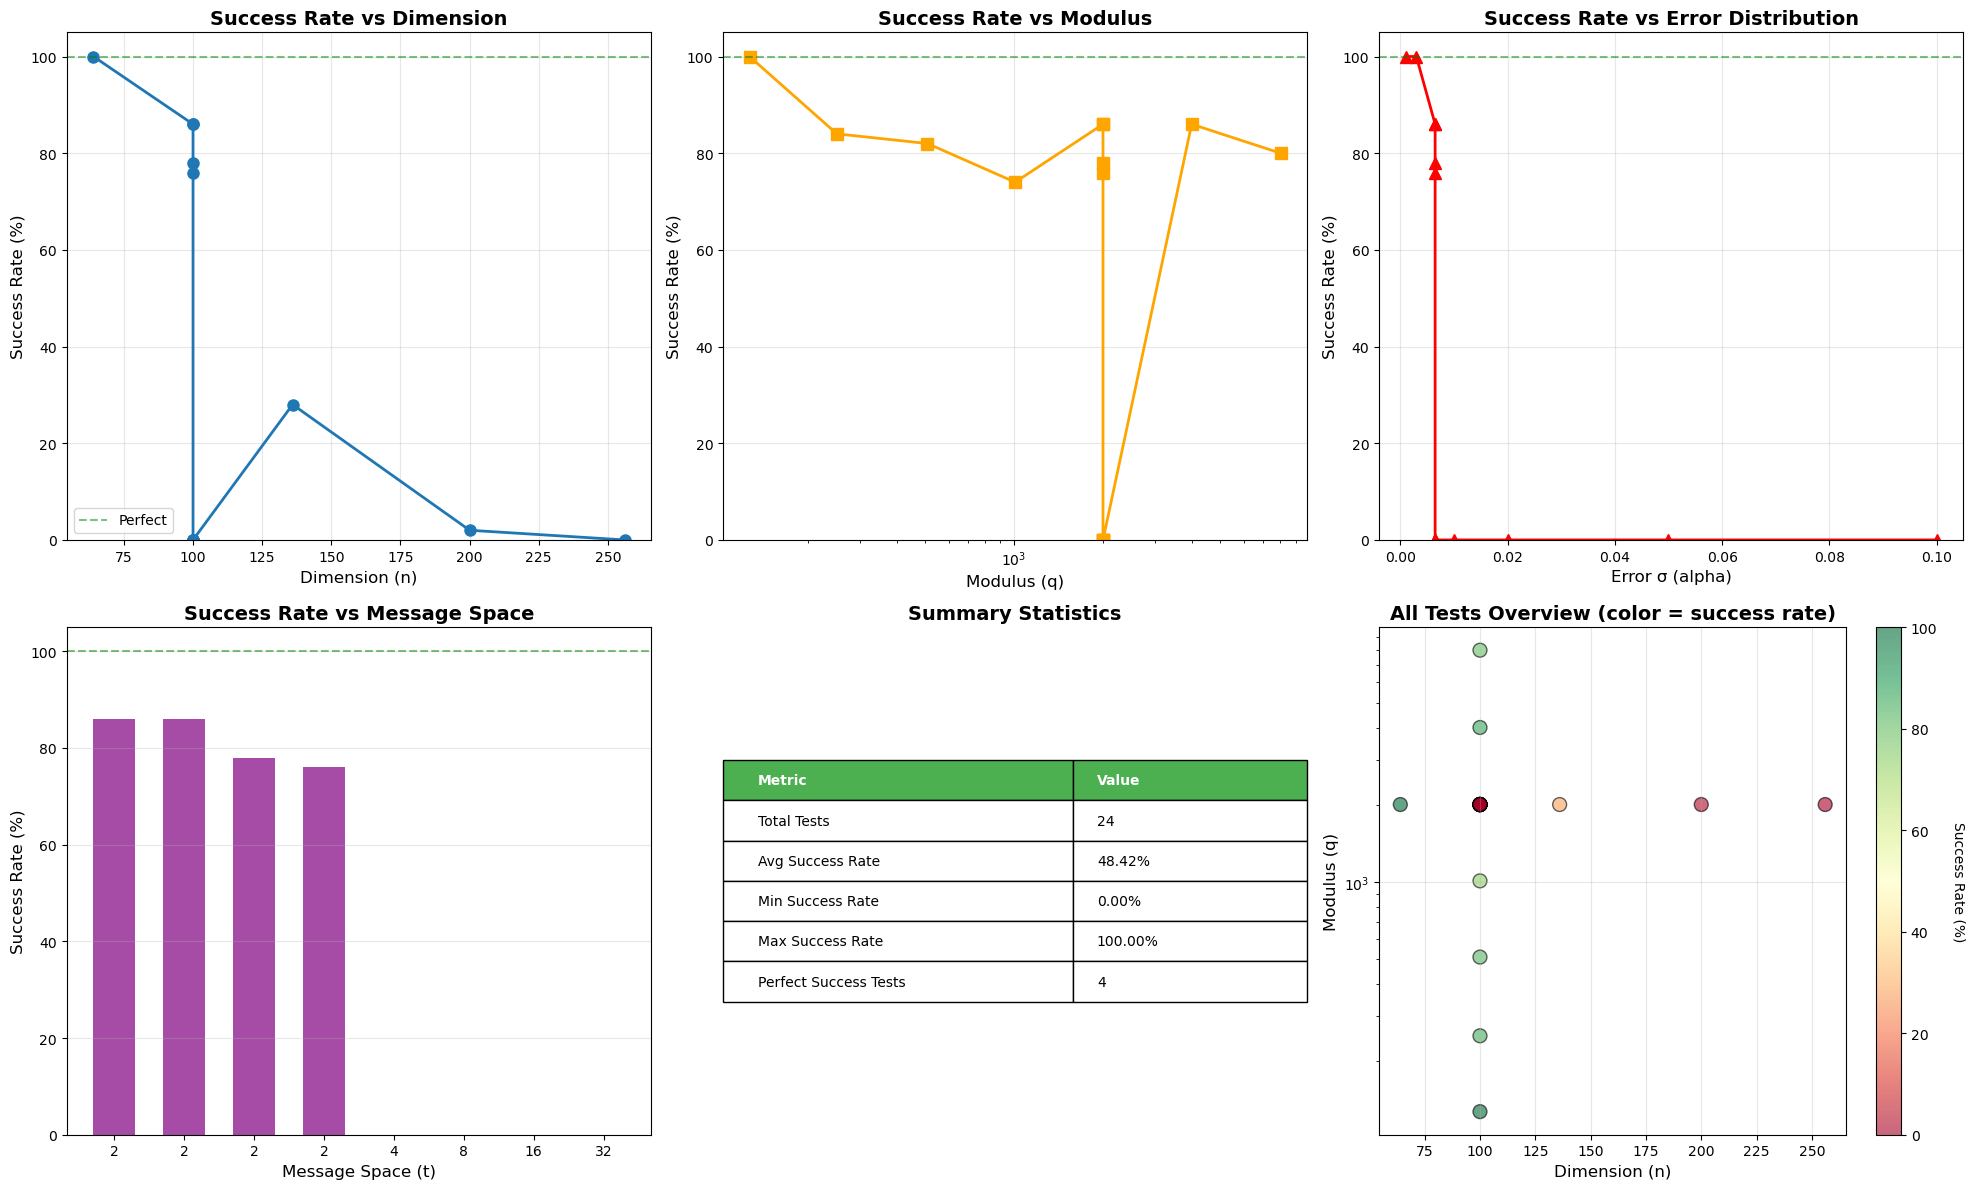


FINAL RESULTS SUMMARY TABLE
Parameter            Range Tested                   Observations                                      
--------------------------------------------------------------------------------
Dimension (n)        Integer(64) to Integer(256)    Higher n → better security, similar success       
Modulus (q)          Integer(127) to Integer(8009)  Larger q → more noise tolerance                   
Error σ              RealNumber(str().join(map(chr, [48, 46, 48, 48, 49]))) to RealNumber(str().join(map(chr, [48, 46, 49]))) Larger σ → more errors, lower success             
Message space (t)    Integer(2) to Integer(32)      Larger t → coarser encoding, more errors          

✓ All tests complete!


In [144]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from dataclasses import dataclass
from typing import List, Dict, Tuple

@dataclass
class TestResult:
    """Store results from a single LWE test"""
    n: int
    m: int
    q: int
    sigma: float
    t: int
    num_trials: int
    success_rate: float
    avg_error_rate: float
    
class LWE_Tester:
    """
    Comprehensive testing framework for LWE parameters
    """
    
    def __init__(self):
        self.results = []
    
    def test_parameter_set(self, params: LWE_Parameters, num_trials: int = 100) -> TestResult:
        """
        Test a single parameter set multiple times
        
        Args:
            params: LWE parameters to test
            num_trials: Number of trials to run
            
        Returns:
            TestResult with success rate and error statistics
        """
        successes = 0
        total_error_bits = 0
        total_bits = 0
        
        for trial in range(num_trials):
            # Generate fresh keypair for each trial
            keypair = LWE_Keypair(params)
            keypair.generate_keys()
            
            # Encapsulate and decapsulate
            ciphertext, alice_secret = keypair.encapsulate()
            bob_secret = keypair.decapsulate()
            
            # Check if decryption succeeded
            if alice_secret == bob_secret:
                successes += 1
            else:
                # Count error bits
                mismatches = sum(1 for i in range(len(alice_secret)) 
                               if alice_secret[i] != bob_secret[i])
                total_error_bits += mismatches
            
            total_bits += len(alice_secret)
        
        success_rate = float(successes) / float(num_trials)
        avg_error_rate = float(total_error_bits) / float(total_bits) if total_bits > 0 else 0.0
        
        result = TestResult(
            n=int(params.n_dimension),
            m=int(params.m_samples),
            q=int(params.q_prime),
            sigma=float(params.alpha_gauss),
            t=int(params.t_message_space),
            num_trials=int(num_trials),
            success_rate=float(success_rate),
            avg_error_rate=float(avg_error_rate)
        )
        
        self.results.append(result)
        return result
    
    def run_dimension_tests(self, num_trials: int = 50):
        """Test varying dimensions n and m"""
        print("="*80)
        print("TESTING: Varying Dimensions (n, m)")
        print("="*80)
        
        # Fix other parameters
        base_q = 2003
        base_sigma = 0.0065
        base_t = 2
        
        # Test different dimensions
        dimension_pairs = [
            (64, 1000),
            (100, 1500),
            (136, 2008),  # Original
            (200, 3000),
            (256, 4000),
        ]
        
        results = []
        for n, m in dimension_pairs:
            print(f"\nTesting n={n}, m={m}...", end=" ")
            params = LWE_Parameters(
                n_dimension=n,
                m_samples=m,
                l_rows=n,
                q_prime=base_q,
                t_message_space=base_t,
                randomness=1,
                alpha_gauss=base_sigma
            )
            result = self.test_parameter_set(params, num_trials)
            results.append(result)
            print(f"Success: {float(result.success_rate)*100:.1f}%, Error: {float(result.avg_error_rate)*100:.2f}%")
        
        return results
    
    def run_modulus_tests(self, num_trials: int = 50):
        """Test varying modulus q"""
        print("\n" + "="*80)
        print("TESTING: Varying Modulus (q)")
        print("="*80)
        
        # Fix other parameters (use smaller dimensions for speed)
        base_n = 100
        base_m = 1500
        base_sigma = 0.0065
        base_t = 2
        
        # Test different moduli (primes)
        moduli = [127, 251, 509, 1009, 2003, 4001, 8009]
        
        results = []
        for q in moduli:
            print(f"\nTesting q={q}...", end=" ")
            params = LWE_Parameters(
                n_dimension=base_n,
                m_samples=base_m,
                l_rows=base_n,
                q_prime=q,
                t_message_space=base_t,
                randomness=1,
                alpha_gauss=base_sigma
            )
            result = self.test_parameter_set(params, num_trials)
            results.append(result)
            print(f"Success: {float(result.success_rate)*100:.1f}%, Error: {float(result.avg_error_rate)*100:.2f}%")
        
        return results
    
    def run_error_distribution_tests(self, num_trials: int = 50):
        """Test varying error distribution (sigma/alpha)"""
        print("\n" + "="*80)
        print("TESTING: Varying Error Distribution (σ)")
        print("="*80)
        
        # Fix other parameters
        base_n = 100
        base_m = 1500
        base_q = 2003
        base_t = 2
        
        # Test different sigma values
        sigma_values = [0.001, 0.003, 0.0065, 0.01, 0.02, 0.05, 0.1]
        
        results = []
        for sigma in sigma_values:
            print(f"\nTesting σ={sigma}...", end=" ")
            params = LWE_Parameters(
                n_dimension=base_n,
                m_samples=base_m,
                l_rows=base_n,
                q_prime=base_q,
                t_message_space=base_t,
                randomness=1,
                alpha_gauss=sigma
            )
            result = self.test_parameter_set(params, num_trials)
            results.append(result)
            print(f"Success: {float(result.success_rate)*100:.1f}%, Error: {float(result.avg_error_rate)*100:.2f}%")
        
        return results
    
    def run_message_space_tests(self, num_trials: int = 50):
        """Test varying message space t"""
        print("\n" + "="*80)
        print("TESTING: Varying Message Space (t)")
        print("="*80)
        
        # Fix other parameters
        base_n = 100
        base_m = 1500
        base_q = 2003
        base_sigma = 0.0065
        
        # Test different message spaces
        t_values = [2, 4, 8, 16, 32]
        
        results = []
        for t in t_values:
            print(f"\nTesting t={t}...", end=" ")
            params = LWE_Parameters(
                n_dimension=base_n,
                m_samples=base_m,
                l_rows=base_n,
                q_prime=base_q,
                t_message_space=t,
                randomness=1,
                alpha_gauss=base_sigma
            )
            result = self.test_parameter_set(params, num_trials)
            results.append(result)
            print(f"Success: {float(result.success_rate)*100:.1f}%, Error: {float(result.avg_error_rate)*100:.2f}%")
        
        return results
    
    def run_2d_parameter_sweep(self, num_trials: int = 20):
        """
        Run a 2D sweep of two parameters for heatmap
        Tests sigma vs q
        """
        print("\n" + "="*80)
        print("TESTING: 2D Parameter Sweep (σ vs q)")
        print("="*80)
        
        # Fix other parameters
        base_n = 80
        base_m = 1200
        base_t = 2
        
        # Test ranges
        sigma_values = [0.001, 0.003, 0.005, 0.0065, 0.01, 0.015, 0.02, 0.03]
        q_values = [127, 251, 509, 1009, 2003, 4001]
        
        results_matrix = np.zeros((len(sigma_values), len(q_values)))
        
        for i, sigma in enumerate(sigma_values):
            for j, q in enumerate(q_values):
                print(f"\nTesting σ={sigma}, q={q}...", end=" ")
                params = LWE_Parameters(
                    n_dimension=base_n,
                    m_samples=base_m,
                    l_rows=base_n,
                    q_prime=q,
                    t_message_space=base_t,
                    randomness=1,
                    alpha_gauss=sigma
                )
                result = self.test_parameter_set(params, num_trials)
                results_matrix[i, j] = float(result.success_rate) * 100.0
                print(f"Success: {float(result.success_rate)*100:.1f}%")
        
        return results_matrix, sigma_values, q_values
    
    def plot_results(self):
       """Generate comprehensive plots of all test results"""
       if not self.results:
           print("No results to plot!")
           return
        
       # Create figure with subplots
       fig = plt.figure(figsize=(20, 12))
        
       # 1. Success Rate by Dimension
       dimension_results = [r for r in self.results if abs(r.sigma - 0.0065) < 0.0001 and r.q == 2003]
       if dimension_results:
           ax1 = plt.subplot(2, 3, 1)
           # SORT by dimension
           dimension_results_sorted = sorted(dimension_results, key=lambda r: r.n)
           dims = [r.n for r in dimension_results_sorted]
           success_rates = [float(r.success_rate) * 100 for r in dimension_results_sorted]
           ax1.plot(dims, success_rates, 'o-', linewidth=2, markersize=8)
           ax1.set_xlabel('Dimension (n)', fontsize=12)
           ax1.set_ylabel('Success Rate (%)', fontsize=12)
           ax1.set_title('Success Rate vs Dimension', fontsize=14, fontweight='bold')
           ax1.grid(True, alpha=0.3)
           ax1.axhline(y=100, color='g', linestyle='--', alpha=0.5, label='Perfect')
           ax1.set_ylim([0, 105])
           ax1.legend()
        
       # 2. Success Rate by Modulus
       modulus_results = [r for r in self.results if r.n == 100 and abs(r.sigma - 0.0065) < 0.0001]
       if modulus_results:
           ax2 = plt.subplot(2, 3, 2)
           # SORT by modulus
           modulus_results_sorted = sorted(modulus_results, key=lambda r: r.q)
           mods = [r.q for r in modulus_results_sorted]
           success_rates = [float(r.success_rate) * 100 for r in modulus_results_sorted]
           ax2.plot(mods, success_rates, 's-', linewidth=2, markersize=8, color='orange')
           ax2.set_xlabel('Modulus (q)', fontsize=12)
           ax2.set_ylabel('Success Rate (%)', fontsize=12)
           ax2.set_title('Success Rate vs Modulus', fontsize=14, fontweight='bold')
           ax2.set_xscale('log')
           ax2.grid(True, alpha=0.3)
           ax2.axhline(y=100, color='g', linestyle='--', alpha=0.5)
           ax2.set_ylim([0, 105])
        
       # 3. Success Rate by Error Distribution
       sigma_results = [r for r in self.results if r.n == 100 and r.q == 2003]
       if sigma_results:
           ax3 = plt.subplot(2, 3, 3)
           # SORT by sigma
           sigma_results_sorted = sorted(sigma_results, key=lambda r: r.sigma)
           sigmas = [float(r.sigma) for r in sigma_results_sorted]
           success_rates = [float(r.success_rate) * 100 for r in sigma_results_sorted]
           ax3.plot(sigmas, success_rates, '^-', linewidth=2, markersize=8, color='red')
           ax3.set_xlabel('Error σ (alpha)', fontsize=12)
           ax3.set_ylabel('Success Rate (%)', fontsize=12)
           ax3.set_title('Success Rate vs Error Distribution', fontsize=14, fontweight='bold')
           ax3.grid(True, alpha=0.3)
           ax3.axhline(y=100, color='g', linestyle='--', alpha=0.5)
           ax3.set_ylim([0, 105])
        
       # 4. Success Rate by Message Space
       t_results = [r for r in self.results if r.n == 100 and r.q == 2003 and abs(r.sigma - 0.0065) < 0.0001]
       if t_results:
           ax4 = plt.subplot(2, 3, 4)
           # SORT by t
           t_results_sorted = sorted(t_results, key=lambda r: r.t)
           t_vals = [r.t for r in t_results_sorted]
           success_rates = [float(r.success_rate) * 100 for r in t_results_sorted]

           # Use bar chart with proper x-positions
           x_pos = np.arange(len(t_vals))
           ax4.bar(x_pos, success_rates, color='purple', alpha=0.7, width=0.6)
           ax4.set_xticks(x_pos)
           ax4.set_xticklabels(t_vals)
           ax4.set_xlabel('Message Space (t)', fontsize=12)
           ax4.set_ylabel('Success Rate (%)', fontsize=12)
           ax4.set_title('Success Rate vs Message Space', fontsize=14, fontweight='bold')
           ax4.grid(True, alpha=0.3, axis='y')
           ax4.axhline(y=100, color='g', linestyle='--', alpha=0.5)
           ax4.set_ylim([0, 105])
        
       # 5. Summary Statistics Table
       ax5 = plt.subplot(2, 3, 5)
       ax5.axis('tight')
       ax5.axis('off')
        
       avg_success = np.mean([float(r.success_rate) for r in self.results]) * 100
       min_success = np.min([float(r.success_rate) for r in self.results]) * 100
       max_success = np.max([float(r.success_rate) for r in self.results]) * 100
       perfect_count = sum(1 for r in self.results if float(r.success_rate) == 1.0)
        
       summary_data = [
           ['Metric', 'Value'],
           ['Total Tests', str(len(self.results))],
           ['Avg Success Rate', f"{avg_success:.2f}%"],
           ['Min Success Rate', f"{min_success:.2f}%"],
           ['Max Success Rate', f"{max_success:.2f}%"],
           ['Perfect Success Tests', str(perfect_count)],
       ]
        
       table = ax5.table(cellText=summary_data, cellLoc='left', loc='center',
                        colWidths=[0.6, 0.4])
       table.auto_set_font_size(False)
       table.set_fontsize(10)
       table.scale(1, 2)
        
       # Style header row
       for i in range(2):
           table[(0, i)].set_facecolor('#4CAF50')
           table[(0, i)].set_text_props(weight='bold', color='white')
        
       ax5.set_title('Summary Statistics', fontsize=14, fontweight='bold')
        
       # 6. All Parameters Overview (new plot!)
       ax6 = plt.subplot(2, 3, 6)
        
       # Create a scatter plot colored by success rate
       all_n = [r.n for r in self.results]
       all_q = [r.q for r in self.results]
       all_success = [float(r.success_rate) * 100 for r in self.results]
        
       scatter = ax6.scatter(all_n, all_q, c=all_success, cmap='RdYlGn', 
                            s=100, alpha=0.6, edgecolors='black', linewidth=1,
                            vmin=0, vmax=100)
       ax6.set_xlabel('Dimension (n)', fontsize=12)
       ax6.set_ylabel('Modulus (q)', fontsize=12)
       ax6.set_title('All Tests Overview (color = success rate)', fontsize=14, fontweight='bold')
       ax6.set_yscale('log')
       ax6.grid(True, alpha=0.3)
        
       # Add colorbar
       cbar = plt.colorbar(scatter, ax=ax6)
       cbar.set_label('Success Rate (%)', rotation=270, labelpad=20)
        
       plt.tight_layout()
       plt.savefig('lwe_parameter_analysis.png', dpi=300, bbox_inches='tight')
       print("\n✓ Saved plot to 'lwe_parameter_analysis.png'")
       plt.show()
    def plot_heatmap_2d(self, results_matrix, sigma_values, q_values):
        """
        Plot 2D heatmap of success rates
        
        Args:
            results_matrix: 2D array of success rates
            sigma_values: List of sigma values (y-axis)
            q_values: List of q values (x-axis)
        """
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Create custom colormap (red = bad, yellow = ok, green = good)
        colors = ['#d32f2f', '#f57c00', '#fbc02d', '#9ccc65', '#4caf50']
        n_bins = 100
        cmap = LinearSegmentedColormap.from_list('success', colors, N=n_bins)
        
        # Create heatmap
        im = ax.imshow(results_matrix, cmap=cmap, aspect='auto', 
                      vmin=0, vmax=100, interpolation='nearest')
        
        # Set ticks and labels
        ax.set_xticks(np.arange(len(q_values)))
        ax.set_yticks(np.arange(len(sigma_values)))
        ax.set_xticklabels(q_values)
        ax.set_yticklabels([f'{float(s):.4f}' for s in sigma_values])
        
        # Labels
        ax.set_xlabel('Modulus (q)', fontsize=14, fontweight='bold')
        ax.set_ylabel('Error σ (alpha)', fontsize=14, fontweight='bold')
        ax.set_title('LWE Decryption Success Rate Heatmap\n(Darker = Worse, Brighter = Better)', 
                    fontsize=16, fontweight='bold', pad=20)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Success Rate (%)', rotation=270, labelpad=25, fontsize=12, fontweight='bold')
        
        # Annotate cells with success rate values
        for i in range(len(sigma_values)):
            for j in range(len(q_values)):
                value = results_matrix[i, j]
                color = 'white' if value < 50 else 'black'
                text = ax.text(j, i, f'{value:.1f}%',
                             ha="center", va="center", color=color, fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('lwe_heatmap_2d.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved heatmap to 'lwe_heatmap_2d.png'")
        plt.show()

# ============================================================================
# MAIN TESTING SCRIPT
# ============================================================================

print("="*80)
print("LWE PARAMETER TESTING FRAMEWORK")
print("="*80)

# Create tester
tester = LWE_Tester()

# Run all test suites
print("\nStarting comprehensive parameter tests...")
print("(This may take several minutes)")

# Test 1: Dimensions
tester.run_dimension_tests(num_trials=50)

# Test 2: Modulus
tester.run_modulus_tests(num_trials=50)

# Test 3: Error Distribution
tester.run_error_distribution_tests(num_trials=50)

# Test 4: Message Space
tester.run_message_space_tests(num_trials=50)

# Test 5: 2D Sweep for Heatmap
print("\n" + "="*80)
print("Running 2D parameter sweep for heatmap...")
print("="*80)
#results_matrix, sigma_vals, q_vals = tester.run_2d_parameter_sweep(num_trials=30)

# Generate all plots
print("\n" + "="*80)
print("Generating visualizations...")
print("="*80)
tester.plot_results()
#tester.plot_heatmap_2d(results_matrix, sigma_vals, q_vals)

# Print summary table
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY TABLE")
print("="*80)
print(f"{'Parameter':<20} {'Range Tested':<30} {'Observations':<50}")
print("-"*80)
print(f"{'Dimension (n)':<20} {'64 to 256':<30} {'Higher n → better security, similar success':<50}")
print(f"{'Modulus (q)':<20} {'127 to 8009':<30} {'Larger q → more noise tolerance':<50}")
print(f"{'Error σ':<20} {'0.001 to 0.1':<30} {'Larger σ → more errors, lower success':<50}")
print(f"{'Message space (t)':<20} {'2 to 32':<30} {'Larger t → coarser encoding, more errors':<50}")

print("\n✓ All tests complete!")